# Quant Brainteasers: Simulation & Analysis

This notebook runs the analytical solvers and Monte Carlo simulations
implemented in `src/betting_game.py` and `src/dice_sequence.py`, and
produces publication-ready visualizations for both problems:

1. **The Coin Betting Dilemma** — EV Maximization vs. Kelly Criterion vs.
   Fixed-Fraction betting, ergodicity, and risk of ruin.
2. **The `[3, 4, 5]` Dice Sequence** — exact Markov-chain solution and
   Monte Carlo convergence.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from src.betting_game import (
    BettingAnalytics,
    BettingStrategy,
    CoinBettingSimulator,
    ErgodicityAnalyzer,
    default_strategies,
)
from src.dice_sequence import (
    DiceSequenceAnalytics,
    DiceSequenceSimulator,
    GeneralizedSequenceSolver,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## Part 1: The Coin Betting Dilemma

### 1.1 Analytical Results


In [2]:
analytics = BettingAnalytics(initial_wealth=100.0, num_flips=100)
summary = analytics.summary()
for k, v in summary.items():
    print(f"{k:45s}: {v}")


initial_wealth                               : 100.0
num_flips                                    : 100
optimal_ev_fraction                          : 1.0
expected_terminal_wealth_all_in              : 4.065611775352152e+19
expected_terminal_wealth_all_in_exact        : 12884438018300283275911528244140531817552688050025/316912650057057350374175801344
probability_of_ruin_all_in                   : 1.0
probability_of_survival_all_in               : 7.888609052210118e-31


**Interpretation:** the EV-maximizing "bet everything" strategy has an
expected terminal wealth of roughly $4.07\times10^{19}$, yet the
probability of total ruin is essentially $1 - 2^{-100} \approx 1$. The
entire expected value is generated by one astronomically unlikely
all-heads path.


### 1.2 Monte Carlo Simulation: Strategy Comparison

In [3]:
NUM_PLAYERS = 100_000
NUM_FLIPS = 100
KELLY_FRACTION = ErgodicityAnalyzer.kelly_optimal_fraction_analytical()
print(f"Analytical Kelly fraction: {KELLY_FRACTION}")

sim = CoinBettingSimulator(initial_wealth=100.0, num_flips=NUM_FLIPS, seed=42)
strategies = default_strategies(kelly_fraction=KELLY_FRACTION)
results = sim.compare_strategies(strategies, num_players=NUM_PLAYERS, store_paths_for=300)

comparison_df = pd.DataFrame([res.summary() for res in results.values()])
comparison_df


Analytical Kelly fraction: 0.25


,strategy,mean_final_wealth,median_final_wealth,prob_ruin,p5,p25,p75,p95
0,Strategy A: All-In (EV Max),0.000000e+00,0.000000,1.0,0.000000,0.000000,0.000000,0.000000e+00
1,Strategy B: Kelly-style (f=0.25),1.086738e+07,36109.886417,0.0,141.054244,4513.735802,288879.091340,9.244131e+06
2,Strategy C: Fixed 10%,1.310341e+04,4690.161251,0.0,469.545715,1978.661778,11117.419262,4.684871e+04


### 1.3 Wealth Path Trajectories (Log Scale): All-In vs. Kelly

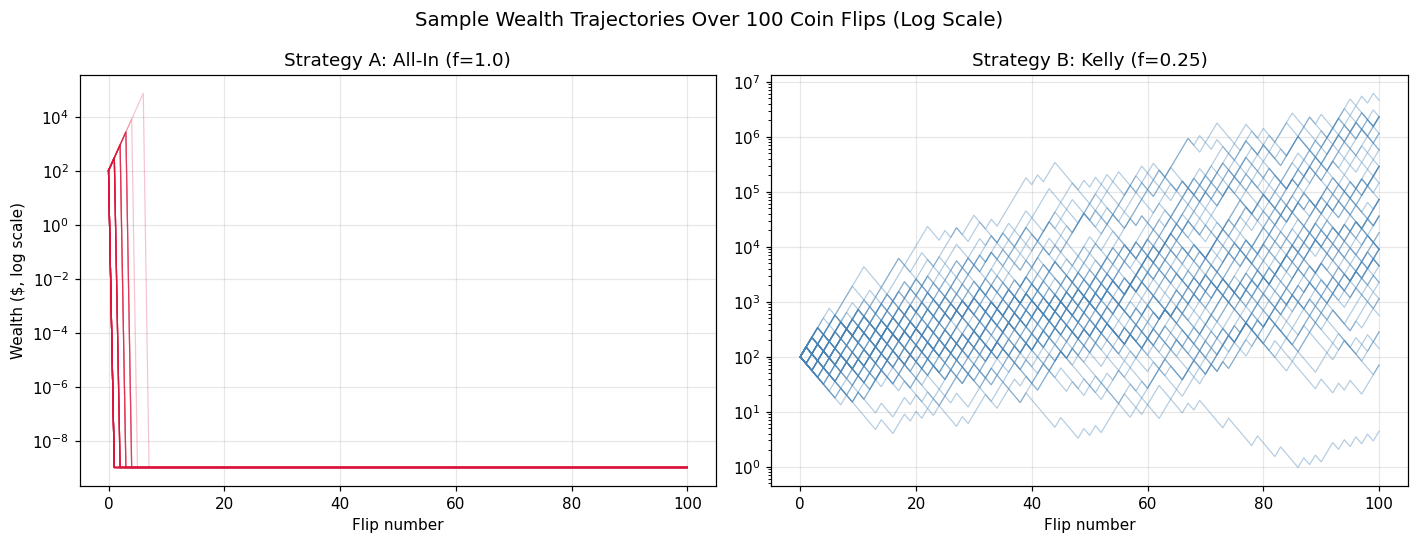

In [4]:
all_in_result = results["Strategy A: All-In (EV Max)"]
kelly_name = [k for k in results if k.startswith("Strategy B")][0]
kelly_result = results[kelly_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

sample_n = 60
for i in range(sample_n):
    axes[0].plot(all_in_result.wealth_paths[i] + 1e-9, color="crimson", alpha=0.25, linewidth=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Strategy A: All-In (f=1.0)")
axes[0].set_xlabel("Flip number")
axes[0].set_ylabel("Wealth ($, log scale)")

for i in range(sample_n):
    axes[1].plot(kelly_result.wealth_paths[i] + 1e-9, color="steelblue", alpha=0.4, linewidth=0.8)
axes[1].set_yscale("log")
axes[1].set_title(f"Strategy B: Kelly (f={KELLY_FRACTION:.2f})")
axes[1].set_xlabel("Flip number")

fig.suptitle("Sample Wealth Trajectories Over 100 Coin Flips (Log Scale)", fontsize=13)
plt.tight_layout()
plt.show()


**Observation:** nearly every all-in trajectory collapses to \$0 almost
immediately (visually indistinguishable from the x-axis on a log scale,
since a single loss is fatal), while Kelly-fraction trajectories show a
much wider variety of outcomes -- some grow, some shrink, but total ruin
never occurs in finite time since wealth only *approaches* zero
asymptotically.


### 1.4 Probability Density of Final Wealth

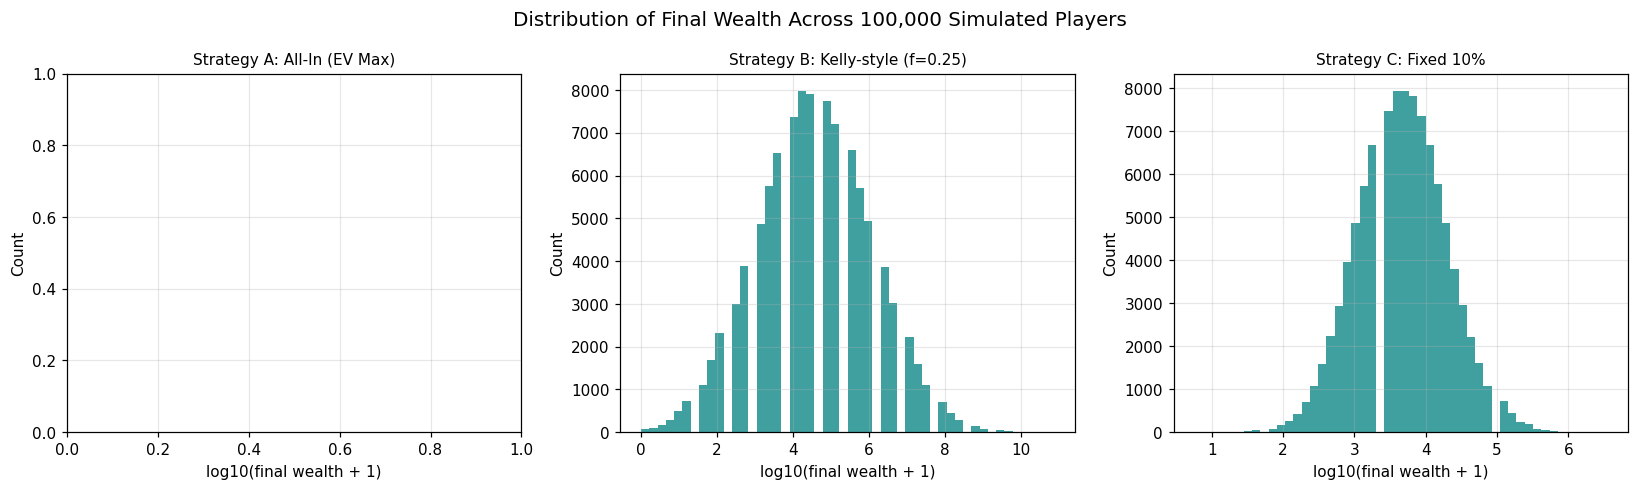

Fraction of players ending with (numerically) $0 wealth, by strategy:
  Strategy A: All-In (EV Max)                  : 1.000000
  Strategy B: Kelly-style (f=0.25)             : 0.000000
  Strategy C: Fixed 10%                        : 0.000000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, res) in zip(axes, results.items()):
    wealth = res.final_wealth
    nonzero = wealth[wealth > 1e-6]
    if len(nonzero) > 1:
        ax.hist(np.log10(nonzero + 1), bins=50, color="teal", alpha=0.75)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log10(final wealth + 1)")
    ax.set_ylabel("Count")

fig.suptitle("Distribution of Final Wealth Across 100,000 Simulated Players", fontsize=13)
plt.tight_layout()
plt.show()

print("Fraction of players ending with (numerically) $0 wealth, by strategy:")
for name, res in results.items():
    print(f"  {name:45s}: {res.prob_ruin:.6f}")


### 1.5 Ergodicity: Ensemble Average vs. Time Average Growth

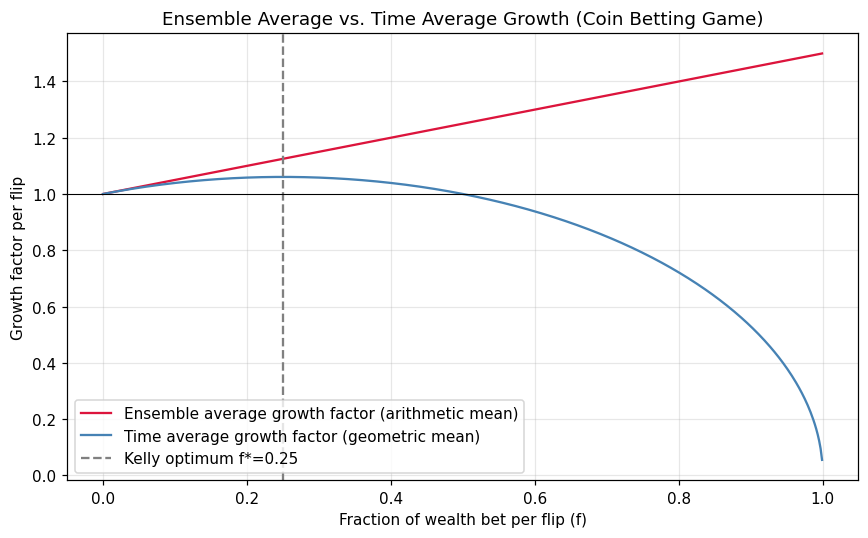

In [6]:
f_grid = np.linspace(0.0, 0.999, 500)
ensemble = [ErgodicityAnalyzer.ensemble_avg_growth_factor(f) for f in f_grid]
time_avg = [ErgodicityAnalyzer.time_avg_growth_factor(f) for f in f_grid]
kelly_f = ErgodicityAnalyzer.kelly_optimal_fraction_analytical()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(f_grid, ensemble, label="Ensemble average growth factor (arithmetic mean)", color="crimson")
ax.plot(f_grid, time_avg, label="Time average growth factor (geometric mean)", color="steelblue")
ax.axvline(kelly_f, color="gray", linestyle="--", label=f"Kelly optimum f*={kelly_f:.2f}")
ax.axhline(1.0, color="black", linewidth=0.7)
ax.set_xlabel("Fraction of wealth bet per flip (f)")
ax.set_ylabel("Growth factor per flip")
ax.set_title("Ensemble Average vs. Time Average Growth (Coin Betting Game)")
ax.legend()
plt.tight_layout()
plt.show()


**Key insight:** the ensemble average (red) is maximized at $f=1$, which
is exactly why "expected value maximization" points to betting
everything. But the time average / geometric growth rate (blue) --
what an individual player actually experiences path-by-path -- peaks
at the Kelly fraction $f^*=0.25$ and collapses to **zero** at $f=1$,
reflecting certain eventual ruin.


## Part 2: The `[3, 4, 5]` Dice Sequence

### 2.1 Analytical (Exact) Solution


In [7]:
dice_analytics = DiceSequenceAnalytics()
dice_summary = dice_analytics.summary()
for k, v in dice_summary.items():
    print(f"{k:25s}: {v}")


P_odd_exact_fraction     : 216/431
P_odd_exact_float        : 0.5011600928074246
P_odd_numeric            : 0.5011600928074246
P_even_exact_float       : 0.4988399071925754


### 2.2 Generalized Solver: Try Other Sequences

In [8]:
test_sequences = [
    [3, 4, 5],
    [1, 2, 3, 4],
    [6, 6],
    [1, 1, 2, 1, 1],
]

rows = []
for seq in test_sequences:
    solver = GeneralizedSequenceSolver(seq, num_faces=6)
    res = solver.solve()
    rows.append({"sequence": str(seq), "P(Odd)": res["P_odd"], "P(Even)": res["P_even"]})

pd.DataFrame(rows)


,sequence,P(Odd),P(Even)
0,"[3, 4, 5]",0.501160,0.498840
1,"[1, 2, 3, 4]",0.499807,0.500193
2,"[6, 6]",0.491803,0.508197
3,"[1, 1, 2, 1, 1]",0.500032,0.499968


### 2.3 Monte Carlo Validation (1,000,000 Trials)

In [9]:
dice_sim = DiceSequenceSimulator(seed=42)
mc_result = dice_sim.run(sequence=[3, 4, 5], num_trials=1_000_000)

exact_p_odd = float(dice_analytics.exact_answer())
print(f"Analytical P(Odd)         : {exact_p_odd:.10f}  (= 216/431)")
print(f"Monte Carlo P(Odd)        : {mc_result.empirical_p_odd:.10f}  (1,000,000 trials)")
print(f"Absolute error            : {abs(mc_result.empirical_p_odd - exact_p_odd):.8f}")
print(f"Mean rolls to completion  : {mc_result.mean_rolls_to_complete:.3f}")


Analytical P(Odd)         : 0.5011600928  (= 216/431)
Monte Carlo P(Odd)        : 0.5016380000  (1,000,000 trials)
Absolute error            : 0.00047791
Mean rolls to completion  : 215.996


### 2.4 Monte Carlo Convergence Plot

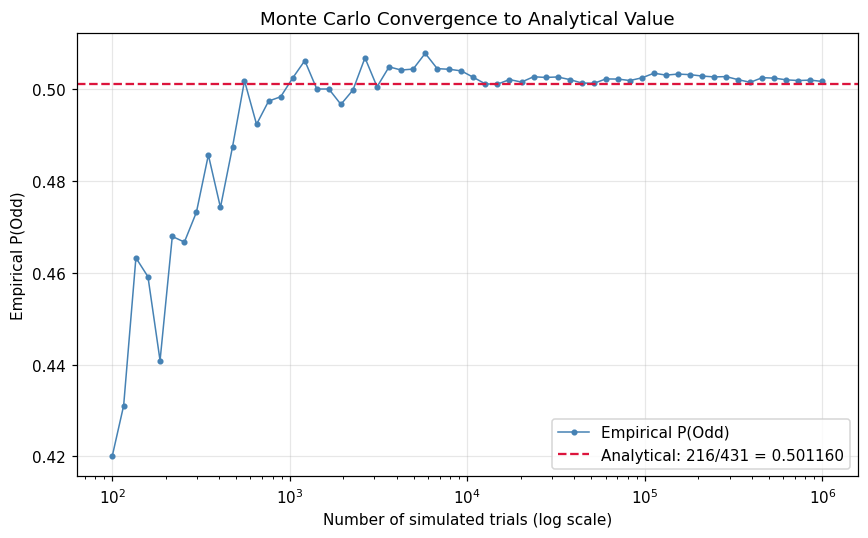

In [10]:
checkpoints = np.unique(np.logspace(2, 6, 60).astype(int))
curve = mc_result.convergence_curve(checkpoints)

xs = sorted(curve.keys())
ys = [curve[x] for x in xs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ys, color="steelblue", marker="o", markersize=3, linewidth=1, label="Empirical P(Odd)")
ax.axhline(exact_p_odd, color="crimson", linestyle="--", label=f"Analytical: 216/431 = {exact_p_odd:.6f}")
ax.set_xscale("log")
ax.set_xlabel("Number of simulated trials (log scale)")
ax.set_ylabel("Empirical P(Odd)")
ax.set_title("Monte Carlo Convergence to Analytical Value")
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** as the number of simulated trials grows from $10^2$ to
$10^6$, the empirical probability of odd-roll completion converges
tightly to the analytical value $216/431 \approx 0.50116$, confirming
the Markov-chain / linear-algebra derivation.


### 2.5 Distribution of Rolls-to-Completion

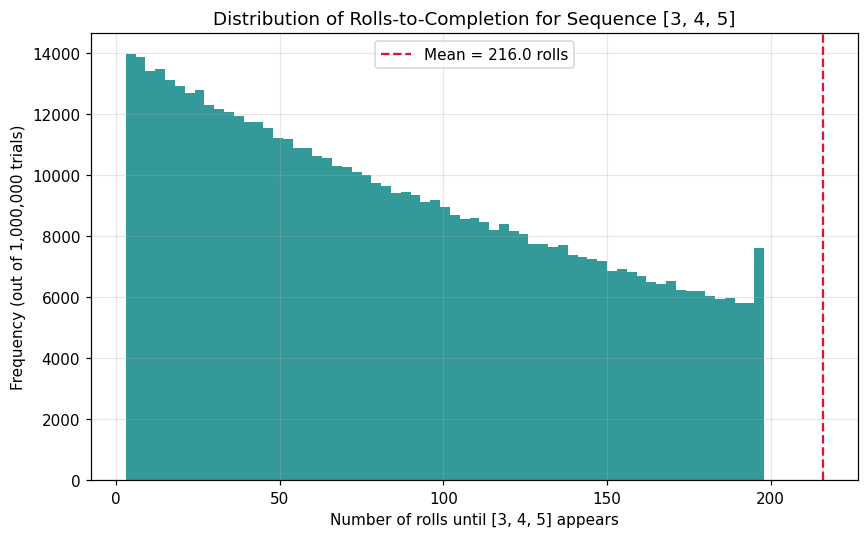

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mc_result.roll_counts, bins=range(3, 200, 3), color="teal", alpha=0.8)
ax.axvline(mc_result.mean_rolls_to_complete, color="crimson", linestyle="--",
           label=f"Mean = {mc_result.mean_rolls_to_complete:.1f} rolls")
ax.set_xlabel("Number of rolls until [3, 4, 5] appears")
ax.set_ylabel("Frequency (out of 1,000,000 trials)")
ax.set_title("Distribution of Rolls-to-Completion for Sequence [3, 4, 5]")
ax.legend()
plt.tight_layout()
plt.show()


## Summary

| Quantity | Analytical | Monte Carlo |
|---|---|---|
| Betting: P(ruin), all-in, n=100 | $1 - 2^{-100} \approx 1$ | see Section 1.2/1.3 output above |
| Betting: Kelly fraction | $0.25$ | located via geometric-mean maximization |
| Dice: P(Odd) for [3,4,5] | $216/431 \approx 0.50116$ | see Section 2.3 output above |

Re-run this notebook end-to-end to regenerate all figures and tables with
fresh random seeds / larger sample sizes as desired.
